# 🚀 Pasqal Interview Prep — Python & Pulser

Write the code yourself in each cell. Hints and syntax reminders are provided.

---

## Part 1: Python Refresher

### 1.1 — Dictionaries

A **dictionary** maps keys to values. Syntax:
```python
my_dict = {"key1": value1, "key2": value2}
my_dict["key1"]       # access a value
len(my_dict)          # number of entries
my_dict.keys()        # all keys
my_dict.values()      # all values
my_dict.items()       # all (key, value) pairs
```

**Exercise**: Create a dict `atoms` mapping atom names to (x,y) tuples:
- `"q0"` → `(0, 0)`, `"q1"` → `(5, 0)`, `"q2"` → `(2.5, 4.33)`

Then print the number of atoms and all atom names.

In [6]:
# YOUR CODE HERE
atoms = {"q0":(0,0), "q1":(5,0), "q2":(2.5,4.33)}
print(len(atoms))
print(atoms.keys())


3
dict_keys(['q0', 'q1', 'q2'])


### 1.2 — List Comprehensions

A **list comprehension** builds a list in one line. Syntax:
```python
# Basic:
[expression for item in iterable]

# With filter:
[expression for item in iterable if condition]

# Examples:
squares = [x**2 for x in range(5)]           # [0, 1, 4, 9, 16]
evens = [x for x in range(10) if x % 2 == 0] # [0, 2, 4, 6, 8]
```

To iterate over dict items: `for name, coords in my_dict.items()`
To access tuple elements: `coords[0]` is x, `coords[1]` is y.

**Exercise**: Using your `atoms` dict, create a list of atom names whose x-coordinate is > 0. One line.

In [7]:
# YOUR CODE HERE
xpositive = [atomName for atomName in atoms if atoms[atomName][0] > 0]

### 1.3 — Functions & Type Hints

Function syntax in Python:
```python
def function_name(param1: type, param2: type = default) -> return_type:
    """Docstring explaining what it does."""
    result = param1 + param2
    return result
```

Type hints (`: type` and `-> type`) don't enforce anything — they're documentation.

Useful: `math.sqrt(x)` for square root.

**Exercise**: Write `distance(a: tuple, b: tuple) -> float` returning the Euclidean distance between two 2D points.

Formula: `sqrt((x2-x1)² + (y2-y1)²)`

Test: `distance((0,0), (3,4))` should return `5.0`.

In [8]:
import math

# YOUR CODE HERE
def distance(a: tuple, b: tuple) -> float:
    return math.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2)

print(distance((0,0), (3,4)))

5.0


### 1.4 — Sorting with Lambda

`sorted()` returns a new sorted list. The `key` parameter tells it *what* to sort by:
```python
# Sort a list of tuples by second element:
sorted([("a", 3), ("b", 1)], key=lambda x: x[1])  # [("b", 1), ("a", 3)]

# Lambda is just a mini function:
# lambda x: x[1]  is the same as  def f(x): return x[1]

# dict.items() gives you (key, value) pairs:
for name, coords in my_dict.items():
    print(name, coords)
```

**Exercise**: Sort `atoms.items()` by y-coordinate (ascending). Print each atom name and y-coord.

In [21]:
sortedAtoms = sorted(atoms.items(), key=lambda x: x[1][1])
# YOUR CODE HERE

for atomNate, coords in sortedAtoms:
    print(atomNate, coords)

q0 (0, 0)
q1 (5, 0)
q2 (2.5, 4.33)


### 1.5 — Classes

```python
class MyClass:
    def __init__(self, param1: str, param2: int = 10):
        self.param1 = param1   # store as instance attribute
        self.param2 = param2
    
    def my_method(self) -> str:
        return f"Values: {self.param1}, {self.param2}"

obj = MyClass("hello")
print(obj.my_method())
```

- `self` = the instance itself (like `this` in Java)
- `f"...{variable}..."` = f-string (string interpolation)

**Exercise**: Create a `Job` class with:
- `__init__` taking `name: str`, `target: str`, `shots: int = 100`
- Method `summary() -> str` returning `"Job 'name' on target (shots shots)"`

Create one and print its summary.

In [22]:
# YOUR CODE HERE
class Job:
    def __init__(self, name: str, target: str, shots: int = 100):
        self.name = name
        self.target = target
        self.shots = shots

    def summary(self) -> str:
        return f"Job {self.name} on target {self.target} shots {self.shots}"

tmp = Job("Test", "TestTarget")
print(tmp.summary())

Job Test on target TestTarget shots 100


### 1.6 — Exception Handling

```python
try:
    result = risky_operation()
except SomeError:
    result = fallback_value
```

**Exercise**: Write `safe_divide(a, b)` that returns `a / b`, but returns `None` if b is zero.

Test: `safe_divide(10, 0)` → `None`, `safe_divide(10, 3)` → `3.333...`

In [23]:
def safe_divide(a,b):
    try:
        return a/b
    except ZeroDivisionError:
        return None

print(safe_divide(10,0))
print(safe_divide(10,3))

None
3.3333333333333335


### 1.7 — Generators

A generator is a function that `yield`s values one at a time instead of returning a list:
```python
def count_up(n):
    i = 0
    while i < n:
        yield i    # pauses here, gives value, resumes on next call
        i += 1

for num in count_up(3):
    print(num)  # 0, 1, 2
```

**Exercise**: Write `fibonacci(n)` that yields the first `n` Fibonacci numbers (0, 1, 1, 2, 3, 5, 8...).

Hint: keep two variables `a, b = 0, 1` and update with `a, b = b, a + b`.

In [26]:
def fibonacci(n):
    a = 0
    b = 1
    i = 0
    while i < n:
        yield a
        a, b = b, a + b
        # pauses here, gives value, resumes on next call
        i += 1


for num in fibonacci(10):
    print(num)  # 0, 1, 2

0
1
1
2
3
5
8
13
21
34


### 1.8 — Decorators

A decorator wraps a function to add behavior:
```python
def my_decorator(func):          # takes a function
    def wrapper(*args, **kwargs): # replacement function
        print("Before")
        result = func(*args, **kwargs)  # call original
        print("After")
        return result
    return wrapper                # return the wrapper

@my_decorator   # same as: say_hi = my_decorator(say_hi)
def say_hi():
    print("Hi!")
```

Useful: `time.time()` returns current time in seconds.

**Exercise**: Write a `@timer` decorator that prints how long a function takes.

Apply it to a function that sums `range(1_000_000)`.

In [34]:
import time

def timer(func):
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        end = time.time()
        print(end-start)
        return result
    return wrapper

@timer
def somme(n: int):
    sum = 0
    for i in range(n):
        sum += i
    return sum

somme(10000)


0.00021004676818847656


49995000

---

## Part 2: Pulser — Programming Quantum Atoms

### What is Pulser?

Pasqal's quantum computers work by trapping **real atoms** using lasers. Pulser is the Python library that lets you control this. Here's the mental model:

1. **Register** = the physical layout of atoms. Imagine a table where you place marbles at specific (x, y) positions. Each marble is an atom = a qubit.

2. **Device** = the physical machine with its constraints (max atoms, available laser channels, min distances between atoms, etc.)

3. **Sequence** = a timeline of instructions. "At time 0, fire this laser for 1000ns. Then fire that laser for 500ns." It's tied to a register + device.

4. **Pulse** = a single laser instruction. It has:
   - **amplitude** (Ω): how strong the laser is
   - **detuning** (δ): frequency offset of the laser
   - **duration**: how long in nanoseconds
   - These control what happens to the atoms' quantum states

5. **Simulation** = run the sequence on your laptop (no real QPU needed). You get measurement results: which atoms ended up in state 0 vs state 1.

`.draw()` = visualize. On a register it shows atom positions. On a sequence it shows the pulse timeline.

---

### 2.1 — Create a Register

A register is just a dict of `{name: (x, y)}` wrapped in a `Register` object.

```python
from pulser import Register

reg = Register({"atom0": (0, 0), "atom1": (10, 0)})
reg.draw()  # shows a plot of atom positions
```

**Exercise**: Create a triangular register with 3 atoms spaced ~8µm apart. Draw it.

Hint: equilateral triangle with side 8 → coords `(0,0)`, `(8,0)`, `(4, 6.93)`

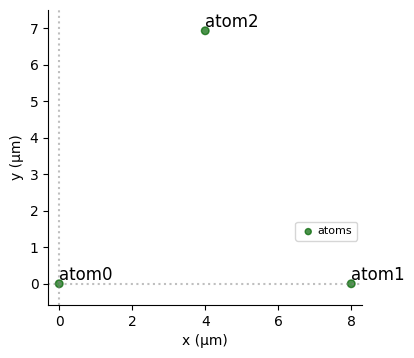

In [37]:
from pulser import Register

# YOUR CODE HERE
reg = Register({"atom0": (0,0), "atom1":(8,0), "atom2":(4,6.93)})

reg.draw()

### 2.2 — Explore the Device

The device defines physical constraints of the real machine.

```python
from pulser.devices import AnalogDevice

print(AnalogDevice.name)
print(AnalogDevice.max_atom_num)
print(AnalogDevice.channels)  # dict of available laser channels
```

**Exercise**: Import `AnalogDevice` and print its name, max atoms, and channel names.

In [38]:
# YOUR CODE HERE
from pulser.devices import AnalogDevice

print(AnalogDevice.name)
print(AnalogDevice.max_atom_num)
print(AnalogDevice.channels)  # dict of available laser channels

AnalogDevice
80
{'rydberg_global': Rydberg(addressing='Global', max_abs_detuning=125.66370614359172, max_amp=12.566370614359172, min_retarget_interval=None, fixed_retarget_t=None, max_targets=None, clock_period=4, min_duration=16, max_duration=100000000, min_avg_amp=0, mod_bandwidth=8, custom_phase_jump_time=None, eom_config=RydbergEOM(limiting_beam=<RydbergBeam.RED: 2>, max_limiting_amp=188.49555921538757, intermediate_detuning=2827.4333882308138, controlled_beams=(<RydbergBeam.BLUE: 1>,), mod_bandwidth=40, custom_buffer_time=240, multiple_beam_control=True, blue_shift_coeff=1.0, red_shift_coeff=1.0), propagation_dir=None)}


### 2.3 — Build a Sequence

A sequence ties a register to a device and holds your pulse timeline.

```python
from pulser import Sequence

seq = Sequence(register, AnalogDevice)
seq.declare_channel("my_channel", "rydberg_global")  # name it, pick a channel type
```

`"rydberg_global"` = a laser channel that hits ALL atoms at once.

**Exercise**: Create a sequence with your register and AnalogDevice. Declare a `"rydberg_global"` channel.

In [39]:
from pulser import Sequence
from pulser.devices import AnalogDevice

# YOUR CODE HERE
seq = Sequence(reg, AnalogDevice)
seq.declare_channel("zohaChannel", "rydberg_global")

### 2.4 — Create and Add a Pulse

A pulse = one laser instruction with amplitude, detuning, duration.

```python
from pulser import Pulse

pulse = Pulse.ConstantPulse(duration=1000, amplitude=5.0, detuning=0.0, phase=0.0)
seq.add(pulse, "my_channel")  # add to the channel you declared
seq.draw()  # shows the pulse timeline
```

**Exercise**: Create a constant pulse (1000ns, amplitude 5.0, detuning 0, phase 0). Add it and draw the sequence.

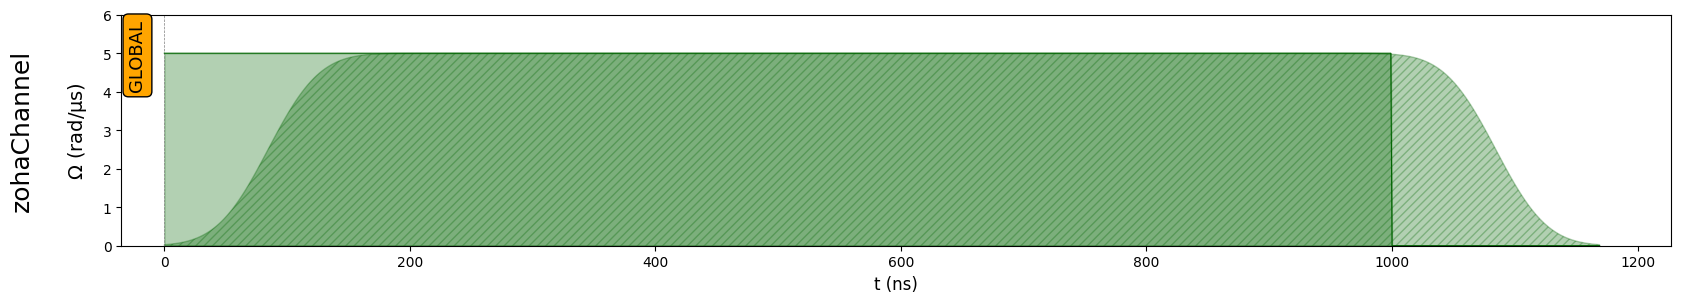

In [41]:
from pulser import Pulse

# YOUR CODE HERE
pulse = Pulse.ConstantPulse(duration=1000, amplitude=5.0, detuning=0.0, phase=0.0)
seq.add(pulse, "zohaChannel")

seq.draw()

### 2.5 — Simulate and Measure

Run your sequence on your laptop and see what the atoms do.

```python
from pulser_simulation import QutipEmulator

sim = QutipEmulator.from_sequence(seq)
results = sim.run()
counts = results.sample_final_state(N_samples=1000)
print(counts)  # e.g. {'000': 450, '010': 230, '101': 320}
```

Each result is a bitstring: `'010'` means atom0=0, atom1=1, atom2=0.
- `0` = ground state (atom is chill)
- `1` = excited state (atom got hit by the laser)

**Exercise**: Simulate your sequence, sample 1000 times, print the results sorted by count (most frequent first).

Hint for sorting: `sorted(counts.items(), key=lambda x: -x[1])`

In [43]:
# YOUR CODE HERE
from pulser_simulation import QutipEmulator

sim = QutipEmulator.from_sequence(seq)
results = sim.run()
counts = results.sample_final_state(N_samples=1000)
print(sorted(counts.items(), key=lambda x: -x[1]))

[('000', 922), ('101', 22), ('011', 20), ('110', 18), ('111', 17), ('001', 1)]


### 2.6 — Experiment!

No instructions — just play. Try:
- Increase amplitude to 15 — what changes?
- Set detuning to -10 — what changes?
- Add a second pulse after the first
- Add more atoms to the register

Observe how measurement outcomes change. No right answers.

In [ ]:
# YOUR PLAYGROUND
Too lazy to do, please tell me what it would do

---

## Part 3: Mini Design Challenge

### 3.1 — Build a Job Manager

This mirrors what Pasqal's cloud platform does: users submit quantum jobs, check status, get results.

Useful tools:
```python
import uuid
job_id = str(uuid.uuid4())  # generates a unique ID like 'a1b2c3d4-...'

from datetime import datetime
now = datetime.now().isoformat()  # '2026-04-01T16:30:00'
```

**Exercise**: Build a `JobManager` class with:
- `submit(name: str, target: str) -> str` — stores a new job with status `"pending"`, returns its ID
- `get(job_id: str) -> dict` — returns job info, raises `KeyError` if not found
- `list_jobs(status: str = None) -> list` — all jobs, optionally filtered
- `complete(job_id: str)` — sets status to `"completed"`

Think: what data structure stores jobs? (hint: dict with job_id as key)

In [51]:
import uuid
from datetime import datetime

class Job:
    def __init__(self, name: str, target: str, status: str = "pending"):
        self.name = name
        self.target = target
        self.status = status

    def summary(self) -> str:
        return f"Job {self.name} on target {self.target} with status {self.status}"

    def print(self):
        print(self.summary())

# YOUR CODE HERE
class JobManager:
    def __init__(self):
        self.jobs = {}

    def submit(self, name: str, target:str) -> str:
        job_id = str(uuid.uuid4())
        self.jobs[job_id] = Job(name=name, target=target)
        return job_id

    def get(self, job_id: str) -> Job:
        try:
            return self.jobs[job_id]
        except KeyError:
            return None

    def get_job(self, job_id: str) -> Job:
        return self.jobs[job_id]

    def list_jobs(self, status: str = None) -> list:
        if status is None:
            return [map(self.get_job, self.jobs.keys())]
        return [job for job in map(self.get_job, self.jobs.keys()) if job["status"] == status]

    def complete(self, job_id: str):
        self.jobs[job_id].status = "completed"


**Test your job manager:**

In [52]:
mgr = JobManager()
id1 = mgr.submit("bell_state", "qpu")
id2 = mgr.submit("grover", "emu_mps")
print("All jobs:", mgr.list_jobs())
mgr.complete(id1)
#print("Pending only:", mgr.list_jobs(status="pending"))
print("Job 1:", mgr.get(id1))


All jobs: [<map object at 0x12bb6f130>]
Job 1: <__main__.Job object at 0x12bb6ffd0>
